# Halving Review Time Impact Analysis

This notebook compares baseline processing time against scenarios where one review step duration is cut in half.

**Outcome metric:** average time from **plan application** (`planning_request`, i.e., end of pre-application activities) to **ready for construction** (`ready_for_construction`).

It is structured to evaluate combinations of staffing levels and pre-application distributions.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_simulation

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


In [9]:
# -----------------------------
# User-editable configuration
# -----------------------------
N_RUNS = 20
NUM_PERMITS = 2000
BASE_SEED = 42
SEQUENTIAL_MODE = "standard"  # standard / parallel / sequential

# Set this to 8 conditions if needed; default below is 9 conditions (3x3).
PRE_APP_DISTS = ["lognormal_10", "lognormal_60", "lognormal_180"]
STAFFING_LEVELS = {
    "Low": {
        "planning_staff_count": 1,
        "public_works_staff_count": 3,
        "fire_staff_count": 2,
    },
    "Medium": {
        "planning_staff_count": 8,
        "public_works_staff_count": 16,
        "fire_staff_count": 4,
    },
    "High": {
        "planning_staff_count": 20,
        "public_works_staff_count": 30,
        "fire_staff_count": 10,
    },
}

CASE_LABELS = [
    "Baseline time",
    "Half planning time",
    "Half public works time",
    "Half fire time",
    "Half special zoning time",
    "Half agency referral time",
]
CASE_MULTIPLIERS = {
    "Baseline time": {},
    "Half planning time": {"planning": 0.5},
    "Half public works time": {"public_works": 0.5},
    "Half fire time": {"fire": 0.5},
    "Half special zoning time": {"special_zoning": 0.5},
    "Half agency referral time": {"agency_referral": 0.5},
}

plt.style.use("ggplot")


def mean_app_to_ready_days(permits):
    durations = [
        p.ready_for_construction - p.planning_request
        for p in permits
        if p.ready_for_construction is not None and p.planning_request is not None
    ]
    return float(np.mean(durations)) if durations else np.nan


def run_condition(dist_name, staffing_name, staffing_cfg, progress_bar=None):
    rows = []
    for run_index in range(N_RUNS):
        seed = BASE_SEED + run_index
        for case in CASE_LABELS:
            sim = run_simulation(
                num_permits=NUM_PERMITS,
                random_seed=seed,
                sequential=SEQUENTIAL_MODE,
                pre_application_distribution=dist_name,
                permit_mix="balanced",
                review_duration_multipliers=CASE_MULTIPLIERS[case],
                planning_staff_count=staffing_cfg["planning_staff_count"],
                public_works_staff_count=staffing_cfg["public_works_staff_count"],
                fire_staff_count=staffing_cfg["fire_staff_count"],
            )
            rows.append({
                "distribution": dist_name,
                "staffing": staffing_name,
                "case": case,
                "run_index": run_index,
                "app_to_ready_days": mean_app_to_ready_days(sim.completed_permits),
            })

            if progress_bar is not None:
                progress_bar.update(1)
                progress_bar.set_postfix_str(f"{staffing_name} | {dist_name} | run {run_index + 1}/{N_RUNS}")

    return pd.DataFrame(rows)


n_conditions = len(STAFFING_LEVELS) * len(PRE_APP_DISTS)
total_tasks = n_conditions * N_RUNS * len(CASE_LABELS)
print(
    f"Starting {total_tasks:,} simulation tasks "
    f"({n_conditions} conditions x {N_RUNS} runs x {len(CASE_LABELS)} cases)."
)

all_frames = []
if tqdm is not None:
    with tqdm(total=total_tasks, desc="Running simulations", unit="sim") as pbar:
        for staffing_name, staffing_cfg in STAFFING_LEVELS.items():
            for dist_name in PRE_APP_DISTS:
                print(f"Condition start: staffing={staffing_name}, pre_app_dist={dist_name}")
                all_frames.append(run_condition(dist_name, staffing_name, staffing_cfg, progress_bar=pbar))
else:
    completed = 0
    for staffing_name, staffing_cfg in STAFFING_LEVELS.items():
        for dist_name in PRE_APP_DISTS:
            print(f"Condition start: staffing={staffing_name}, pre_app_dist={dist_name}")
            df_part = run_condition(dist_name, staffing_name, staffing_cfg, progress_bar=None)
            all_frames.append(df_part)
            completed += N_RUNS * len(CASE_LABELS)
            pct = 100.0 * completed / total_tasks
            print(f"Progress: {completed:,}/{total_tasks:,} ({pct:.1f}%)")

raw_df = pd.concat(all_frames, ignore_index=True)

plot_df = (
    raw_df.groupby(["staffing", "distribution", "case"], as_index=False)["app_to_ready_days"]
    .mean()
)

print("Done. Aggregated results are ready for plotting.")
plot_df.head()


Starting 1,080 simulation tasks (9 conditions x 20 runs x 6 cases).


Running simulations:   0%|          | 0/1080 [00:00<?, ?sim/s]

Condition start: staffing=Low, pre_app_dist=lognormal_10
Condition start: staffing=Low, pre_app_dist=lognormal_60
Condition start: staffing=Low, pre_app_dist=lognormal_180
Condition start: staffing=Medium, pre_app_dist=lognormal_10
Condition start: staffing=Medium, pre_app_dist=lognormal_60
Condition start: staffing=Medium, pre_app_dist=lognormal_180
Condition start: staffing=High, pre_app_dist=lognormal_10
Condition start: staffing=High, pre_app_dist=lognormal_60
Condition start: staffing=High, pre_app_dist=lognormal_180
Done. Aggregated results are ready for plotting.


,staffing,distribution,case,app_to_ready_days
0,High,lognormal_10,Baseline time,166.214260
1,High,lognormal_10,Half agency referral time,164.733705
2,High,lognormal_10,Half fire time,164.976605
3,High,lognormal_10,Half planning time,140.167118
4,High,lognormal_10,Half public works time,164.778963


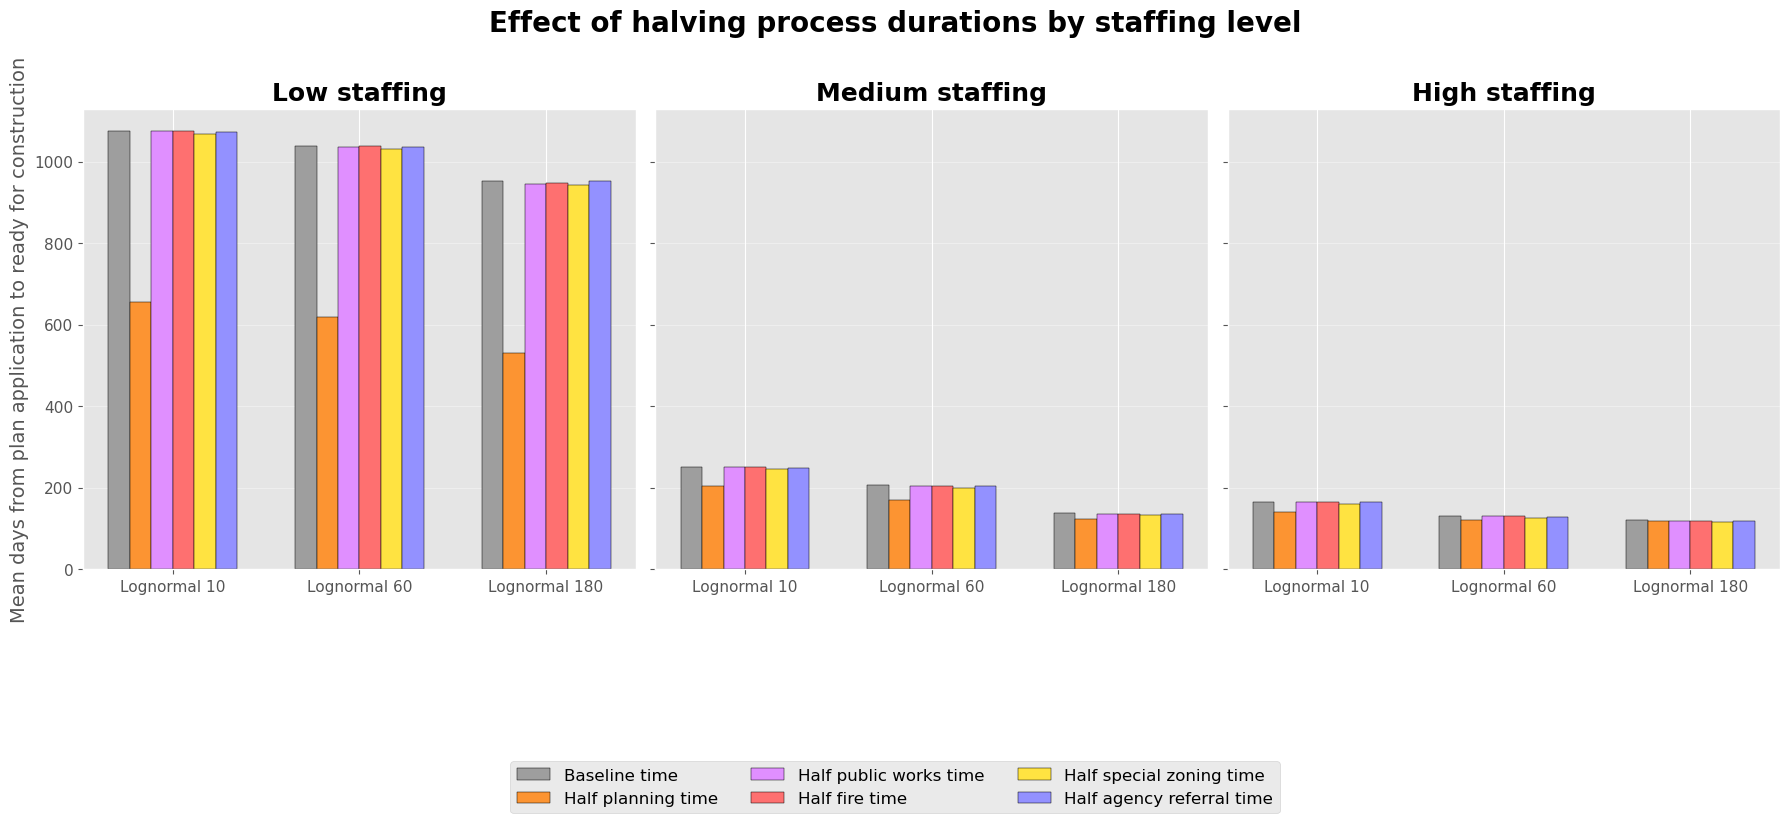

case                    Baseline time  Half agency referral time  \
staffing distribution                                              
Low      lognormal_10     1075.223649                1073.715498   
         lognormal_60     1038.255722                1036.704683   
         lognormal_180     953.292236                 951.767596   
Medium   lognormal_10      251.051910                 249.491892   
         lognormal_60      206.135283                 204.607224   
         lognormal_180     137.699379                 136.221169   
High     lognormal_10      166.214260                 164.733705   
         lognormal_60      130.736839                 129.231758   
         lognormal_180     120.992792                 119.399570   

case                    Half fire time  Half planning time  \
staffing distribution                                        
Low      lognormal_10      1075.937236          654.429858   
         lognormal_60      1038.031408          618.796110   
         lognormal_180      947.876885          529.892593   
Medium   lognormal_10       250.963034          205.187887   
         lognormal_60       205.140730          169.820440   
         lognormal_180      134.967147          122.644161   
High     lognormal_10       164.976605          140.167118   
         lognormal_60       129.964146          121.422029   
         lognormal_180      119.523236          117.918449   

case                    Half public works time  Half special zoning time  
staffing distribution                                                     
Low      lognormal_10              1074.997286               1067.801401  
         lognormal_60              1035.682504               1030.792494  
         lognormal_180              946.189118                943.678419  
Medium   lognormal_10               250.595674                246.251135  
         lognormal_60               204.277713                200.650152  
         lognormal_180              136.019483                132.570768  
High     lognormal_10               164.778963                160.290725  
         lognormal_60               129.617625                124.908200  
         lognormal_180              119.451684                115.094743

In [10]:
# -----------------------------
# Grouped box plots: one panel per staffing; colors = policy case
# (within-run mean app→ready days; spread across runs)
# -----------------------------
import matplotlib.patches as mpatches
from simulation_plot_helpers import show_boxplot_stats_table
from visualize_permits import GANTT_COLORS_OPTION_1 as GANTT_PALETTE

CASE_COLORS = {
    "Baseline time": "#9E9E9E",
    "Half planning time": GANTT_PALETTE["Planning (service)"],
    "Half public works time": GANTT_PALETTE["Public Works (service)"],
    "Half fire time": GANTT_PALETTE["Fire Review (service)"],
    "Half special zoning time": GANTT_PALETTE["Special Zoning"],
    "Half agency referral time": GANTT_PALETTE["Agency Referral (service)"],
}

staffing_order = list(STAFFING_LEVELS.keys())

x = np.arange(len(PRE_APP_DISTS))
n_cases = len(CASE_LABELS)
box_width = 0.125
FONT_TITLE = 18
FONT_AXIS = 14
FONT_TICK = 11
FONT_LEGEND = 12

fig, axes = plt.subplots(
    1,
    len(staffing_order),
    figsize=(18, 7),
    sharey=True,
)
if len(staffing_order) == 1:
    axes = np.array([axes])

group_labels = [d.replace("_", " ").title() for d in PRE_APP_DISTS]
stats_pairs = []

for si, staffing_name in enumerate(staffing_order):
    ax = axes[si]
    for j, dist in enumerate(PRE_APP_DISTS):
        base = float(x[j])
        for i, case in enumerate(CASE_LABELS):
            pts = raw_df.loc[
                (raw_df["staffing"] == staffing_name)
                & (raw_df["distribution"] == dist)
                & (raw_df["case"] == case),
                "app_to_ready_days",
            ].dropna().to_numpy()
            if pts.size == 0:
                continue
            stats_pairs.append((f"{staffing_name} · {dist} · {case}", pts))
            pos = base + (i - (n_cases - 1) / 2) * box_width
            bp = ax.boxplot(
                [pts],
                positions=[pos],
                widths=box_width * 0.92,
                patch_artist=True,
                showfliers=True,
                whis=1.5,
            )
            for patch in bp["boxes"]:
                patch.set_facecolor(CASE_COLORS[case])
                patch.set_edgecolor("black")
                patch.set_linewidth(0.35)
                patch.set_alpha(0.9)

    ax.set_title(f"{staffing_name} staffing", fontsize=FONT_TITLE, fontweight="semibold")
    ax.set_xticks(x)
    ax.set_xticklabels(group_labels, fontsize=FONT_TICK, rotation=0)
    ax.tick_params(axis="y", labelsize=FONT_TICK)
    ax.grid(axis="y", alpha=0.35)
    if si == 0:
        ax.set_ylabel(
            "Days plan application → ready (within-run mean; box across runs)",
            fontsize=FONT_AXIS,
        )
    else:
        ax.tick_params(labelleft=False)

fig.suptitle(
    "Effect of halving process durations by staffing level",
    fontsize=FONT_TITLE + 2,
    fontweight="semibold",
    y=1.02,
)
handles = [
    mpatches.Patch(
        facecolor=CASE_COLORS[c],
        edgecolor="black",
        linewidth=0.35,
        label=c,
    )
    for c in CASE_LABELS
]
fig.legend(
    handles,
    CASE_LABELS,
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    fontsize=FONT_LEGEND,
    frameon=True,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

show_boxplot_stats_table(
    stats_pairs,
    heading="Within-run mean plan application → ready (days); stats match each box",
)

condition_order_all = [(s, d) for s in staffing_order for d in PRE_APP_DISTS]
plot_df.pivot_table(
    index=["staffing", "distribution"],
    columns="case",
    values="app_to_ready_days",
    aggfunc="mean",
).reindex(condition_order_all)
